In [4]:
from itertools import product

In [1]:
# Generic McCulloch-Pits neuron
def mp_neuron(inputs,weights,threshold):
  weighted_sum = sum(x * w for x,w in zip(inputs,weights))

  if weighted_sum >= threshold:
    output = 1

  else: 
    output = 0

  return weighted_sum,output


In [2]:
def print_truth_table(gate_name, num_inputs, weights, threshold):
    print(f"\n========== {gate_name} ==========")
    print("Weights:", weights)
    print("Threshold:", threshold)

    headers = [f"X{i+1}" for i in range(num_inputs)]
    print(" | ".join(headers) + " | Weighted Sum | Output")
    print("-" * 45)

    for inputs in product([0, 1], repeat=num_inputs):
        weighted_sum, output = mp_neuron(inputs, weights, threshold)

        input_values = " | ".join(map(str, inputs))

        print(
            f"{input_values} | "
            f"{weighted_sum:^12} | "
            f"{output}"
        )


In [5]:
and_weights = [1, 1]
and_threshold = 2

print_truth_table(
    "2-INPUT AND GATE",
    2,
    and_weights,
    and_threshold
)



========== 2-INPUT AND GATE ==========
Weights: [1, 1]
Threshold: 2
X1 | X2 | Weighted Sum | Output
---------------------------------------------
0 | 0 |      0       | 0
0 | 1 |      1       | 0
1 | 0 |      1       | 0
1 | 1 |      2       | 1


In [6]:
or_weights = [1, 1]
or_threshold = 1

print_truth_table(
    "2-INPUT OR GATE",
    2,
    or_weights,
    or_threshold
)


========== 2-INPUT OR GATE ==========
Weights: [1, 1]
Threshold: 1
X1 | X2 | Weighted Sum | Output
---------------------------------------------
0 | 0 |      0       | 0
0 | 1 |      1       | 1
1 | 0 |      1       | 1
1 | 1 |      2       | 1


In [7]:
not_weights = [-1]
not_threshold = 0

print_truth_table(
    "NOT GATE",
    1,
    not_weights,
    not_threshold
)


========== NOT GATE ==========
Weights: [-1]
Threshold: 0
X1 | Weighted Sum | Output
---------------------------------------------
0 |      0       | 1
1 |      -1      | 0


In [8]:
and3_weights = [1, 1, 1]
and3_threshold = 3

print_truth_table(
    "3-INPUT AND GATE",
    3,
    and3_weights,
    and3_threshold
)


========== 3-INPUT AND GATE ==========
Weights: [1, 1, 1]
Threshold: 3
X1 | X2 | X3 | Weighted Sum | Output
---------------------------------------------
0 | 0 | 0 |      0       | 0
0 | 0 | 1 |      1       | 0
0 | 1 | 0 |      1       | 0
0 | 1 | 1 |      2       | 0
1 | 0 | 0 |      1       | 0
1 | 0 | 1 |      2       | 0
1 | 1 | 0 |      2       | 0
1 | 1 | 1 |      3       | 1


In [9]:
xor_weights = [1, 1]
xor_threshold = 1

print_truth_table(
    "XOR ATTEMPT USING SINGLE M-P NEURON",
    2,
    xor_weights,
    xor_threshold
)


========== XOR ATTEMPT USING SINGLE M-P NEURON ==========
Weights: [1, 1]
Threshold: 1
X1 | X2 | Weighted Sum | Output
---------------------------------------------
0 | 0 |      0       | 0
0 | 1 |      1       | 1
1 | 0 |      1       | 1
1 | 1 |      2       | 1


In [10]:
print("\n========== EXPECTED XOR TRUTH TABLE ==========")
print("X1 | X2 | Output")
print("----------------")

for x1, x2 in product([0, 1], repeat=2):
    xor_output = x1 ^ x2
    print(f"{x1}  | {x2}  | {xor_output}")



========== EXPECTED XOR TRUTH TABLE ==========
X1 | X2 | Output
----------------
0  | 0  | 0
0  | 1  | 1
1  | 0  | 1
1  | 1  | 0


# Task 02

In [2]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# DATASETS
# ============================================================

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y_and = np.array([0, 0, 0, 1])
y_or  = np.array([0, 1, 1, 1])
y_xor = np.array([0, 1, 1, 0])


# ============================================================
# PERCEPTRON CLASS
# ============================================================

class Perceptron:

    def __init__(self):
        self.weights = None
        self.bias = 0
        self.errors_per_epoch = []


    # --------------------------------------------------------
    # Step Activation Function
    # --------------------------------------------------------
    def step(self, z):
        return np.where(z >= 0, 1, 0)


    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------
    def fit(self, X, y, epochs=20, lr=0.1):

        n_features = X.shape[1]

        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0

        self.errors_per_epoch = []

        for epoch in range(epochs):

            errors = 0

            for xi, target in zip(X, y):

                # Weighted sum
                z = np.dot(xi, self.weights) + self.bias

                # Prediction
                prediction = self.step(z)

                # Error
                error = target - prediction

                # Update weights
                self.weights += lr * error * xi

                # Update bias
                self.bias += lr * error

                # Count misclassifications
                if error != 0:
                    errors += 1

            self.errors_per_epoch.append(errors)

        return self


    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------
    def predict(self, X):

        z = np.dot(X, self.weights) + self.bias

        return self.step(z)

In [3]:
def plot_decision_boundary(model, X, y, title):

    plt.figure(figsize=(6, 5))

    # Plot data points
    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        s=120,
        edgecolors="black"
    )

    # Create x values
    x_values = np.linspace(-0.5, 1.5, 100)


    # Decision boundary:
    # w1*x1 + w2*x2 + b = 0

    if model.weights[1] != 0:

        y_values = (
            -model.weights[0] * x_values - model.bias
        ) / model.weights[1]

        plt.plot(x_values, y_values)

    else:

        # Vertical decision boundary
        if model.weights[0] != 0:

            x_boundary = -model.bias / model.weights[0]

            plt.axvline(x=x_boundary)


    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)

    plt.xlabel("X1")
    plt.ylabel("X2")

    plt.title(title)

    plt.grid(True)

    plt.show()

In [4]:
def plot_errors(model, title):

    plt.figure(figsize=(7, 4))

    plt.plot(
        range(1, len(model.errors_per_epoch) + 1),
        model.errors_per_epoch,
        marker="o"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Number of Misclassifications")

    plt.title(title)

    plt.grid(True)

    plt.show()

### AND Gate

AND Gate
--------------------
Weights: [0.2 0.1]
Bias: -0.20000000000000004

Predictions:
Input: [0 0] Target: 0 Prediction: 0
Input: [0 1] Target: 0 Prediction: 0
Input: [1 0] Target: 0 Prediction: 0
Input: [1 1] Target: 1 Prediction: 1


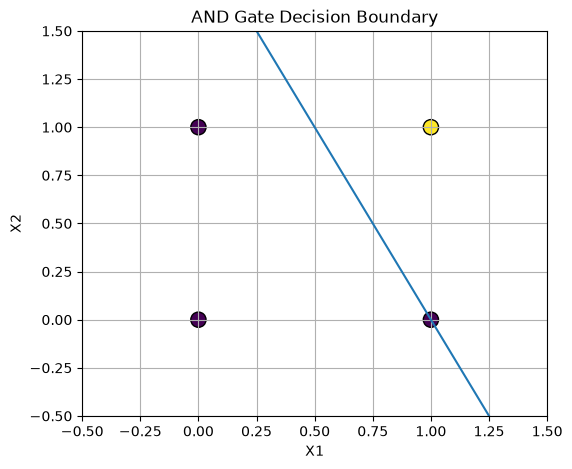

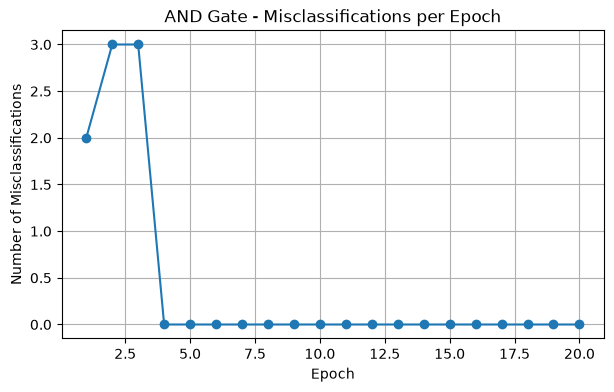

In [5]:
# ============================================================
# AND GATE
# ============================================================

and_model = Perceptron()

and_model.fit(
    X,
    y_and,
    epochs=20,
    lr=0.1
)


print("AND Gate")
print("--------------------")

print("Weights:", and_model.weights)
print("Bias:", and_model.bias)

print("\nPredictions:")

for inputs, target, prediction in zip(
    X,
    y_and,
    and_model.predict(X)
):

    print(
        f"Input: {inputs.astype(int)} "
        f"Target: {target} "
        f"Prediction: {prediction}"
    )


# Decision boundary
plot_decision_boundary(
    and_model,
    X,
    y_and,
    "AND Gate Decision Boundary"
)


# Error curve
plot_errors(
    and_model,
    "AND Gate - Misclassifications per Epoch"
)

### OR Gate


OR Gate
--------------------
Weights: [0.1 0.1]
Bias: -0.1

Predictions:
Input: [0 0] Target: 0 Prediction: 0
Input: [0 1] Target: 1 Prediction: 1
Input: [1 0] Target: 1 Prediction: 1
Input: [1 1] Target: 1 Prediction: 1


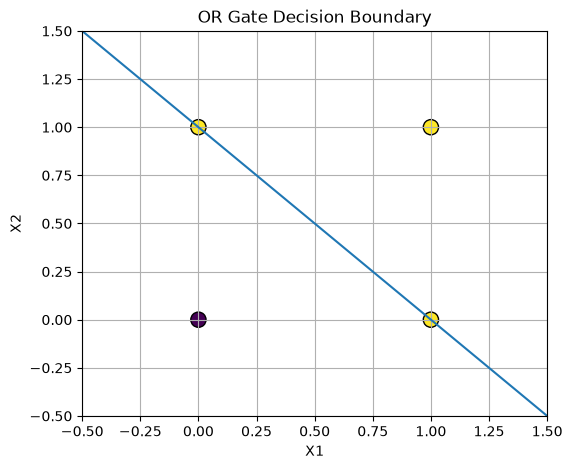

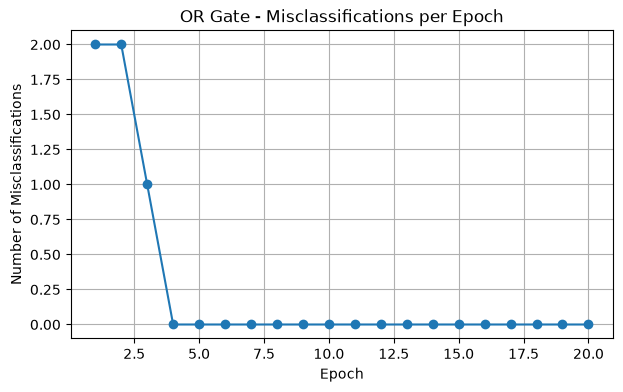

In [6]:
# ============================================================
# OR GATE
# ============================================================

or_model = Perceptron()

or_model.fit(
    X,
    y_or,
    epochs=20,
    lr=0.1
)


print("\nOR Gate")
print("--------------------")

print("Weights:", or_model.weights)
print("Bias:", or_model.bias)

print("\nPredictions:")

for inputs, target, prediction in zip(
    X,
    y_or,
    or_model.predict(X)
):

    print(
        f"Input: {inputs.astype(int)} "
        f"Target: {target} "
        f"Prediction: {prediction}"
    )


# Decision boundary
plot_decision_boundary(
    or_model,
    X,
    y_or,
    "OR Gate Decision Boundary"
)


# Error curve
plot_errors(
    or_model,
    "OR Gate - Misclassifications per Epoch"
)

### XOR Gate


XOR Gate
--------------------
Weights: [-0.1  0. ]
Bias: 0.0

Predictions:
Input: [0 0] Target: 0 Prediction: 1
Input: [0 1] Target: 1 Prediction: 1
Input: [1 0] Target: 1 Prediction: 0
Input: [1 1] Target: 0 Prediction: 0


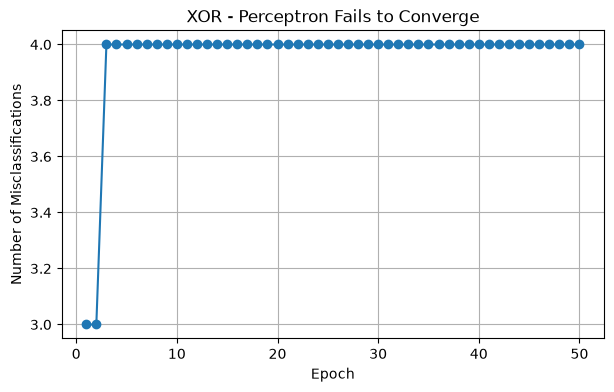

In [7]:
# ============================================================
# XOR GATE
# ============================================================

xor_model = Perceptron()

xor_model.fit(
    X,
    y_xor,
    epochs=50,
    lr=0.1
)


print("\nXOR Gate")
print("--------------------")

print("Weights:", xor_model.weights)
print("Bias:", xor_model.bias)

print("\nPredictions:")

for inputs, target, prediction in zip(
    X,
    y_xor,
    xor_model.predict(X)
):

    print(
        f"Input: {inputs.astype(int)} "
        f"Target: {target} "
        f"Prediction: {prediction}"
    )


# Error curve
plot_errors(
    xor_model,
    "XOR - Perceptron Fails to Converge"
)

### Plot XOR points to show linear inseparability

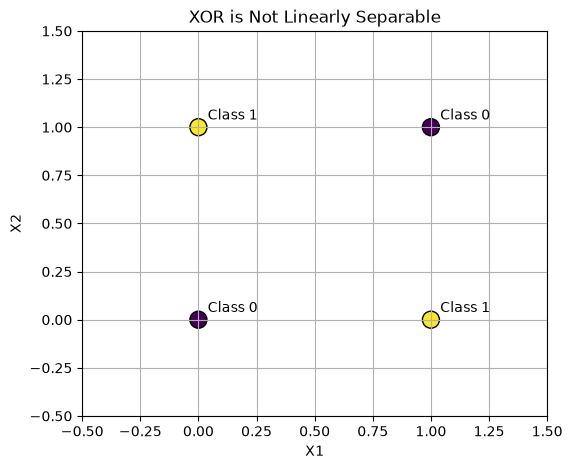

In [8]:
# ============================================================
# XOR POINTS
# ============================================================

plt.figure(figsize=(6, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y_xor,
    s=150,
    edgecolors="black"
)


# Add labels to points
for i in range(len(X)):

    plt.text(
        X[i, 0] + 0.04,
        X[i, 1] + 0.04,
        f"Class {y_xor[i]}"
    )


plt.xlabel("X1")
plt.ylabel("X2")

plt.title("XOR is Not Linearly Separable")

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)

plt.grid(True)

plt.show()

# Task 03

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# xor datset
X = np.array([
   [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
],dtype = float)
# dtype=float tells NumPy to store the values as floating-point numbers like 0.0 and 1.0, which is useful in neural networks because calculations such as weights, gradients, and sigmoid outputs use decimals.

y = np.array([
  [0],
  [1],
  [1
   ],
   [0]
],dtype = float)

def sigmoid(z):
  z = np.clip(z,-500,500)
  return (1/1 + np.exp(-z))

def sigmoid_derivative(a):
  return a * (1-a)

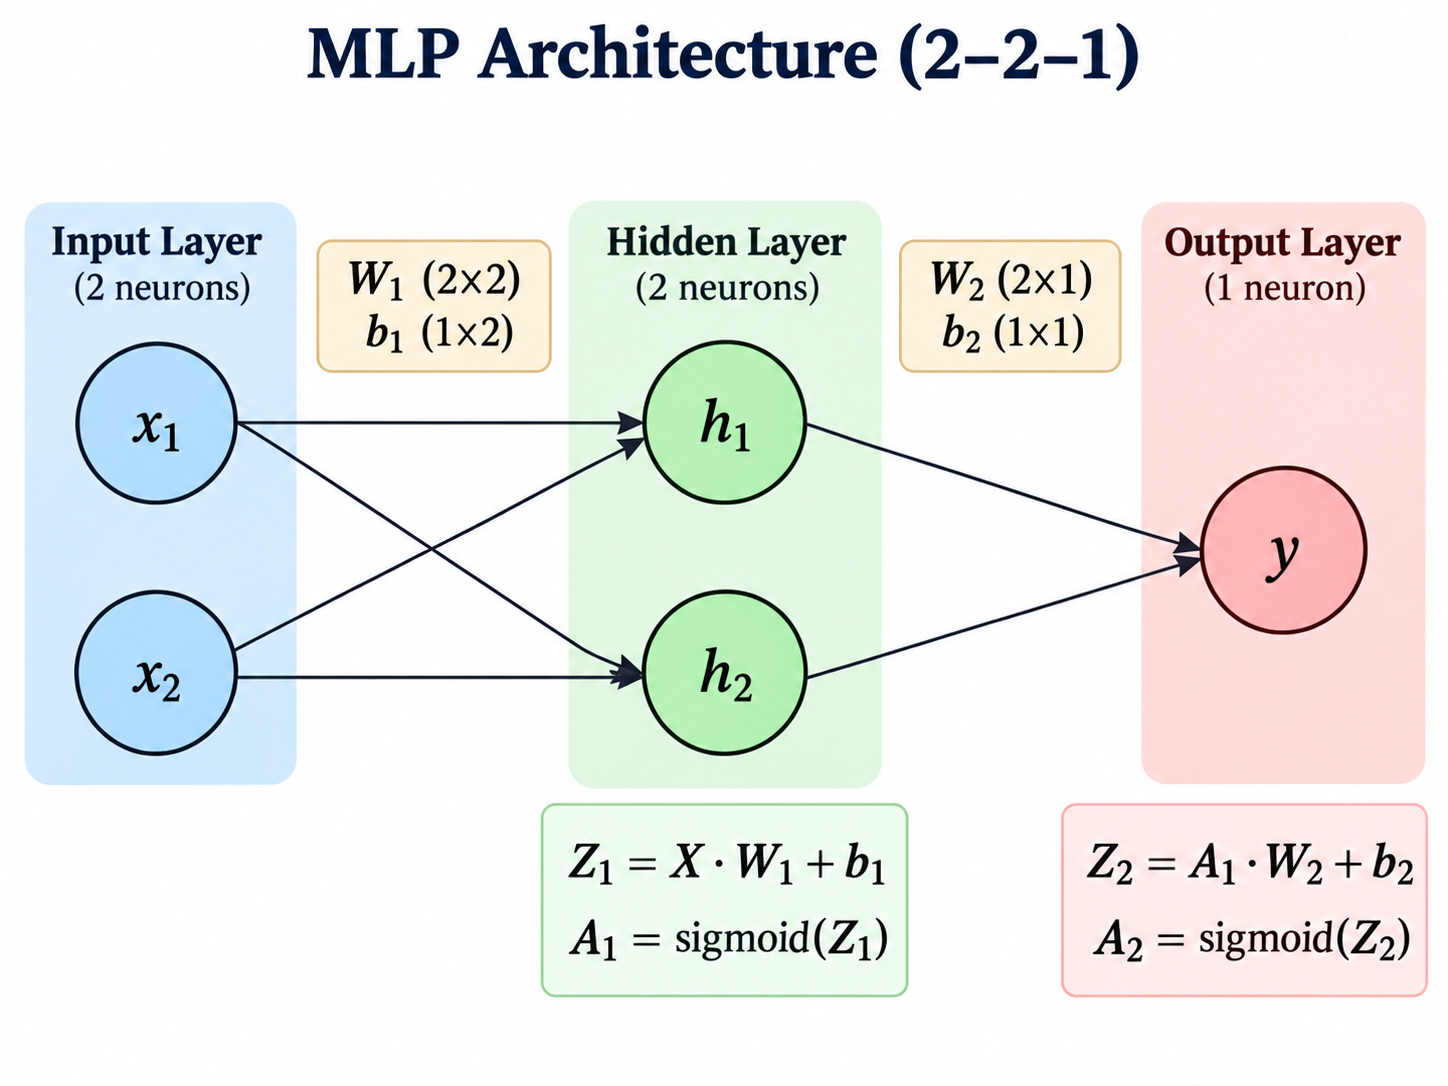




In [1]:
# 2 layer MLP  input->hidden layer -> output lyer
class MLP:
  def __init__(self,input_size = 2,hidden_size = 2,output_size = 1,learning_rate = 0.1,seed = 42):
    np.random.seed(seed)
    self.learning_rate  = learning_rate

    #input -> hidden weights
    self.W1 = np.random.randn(input_size, hidden_size)
    self.b1 = np.zeros((1,hidden_size))

    # Hidden -> Output Weights

    self.W2 = np.random.randn(hidden_size,output_size)

    self.b2 = np.zeros((1,output_size))

  def forward(self, X):
    # Hidden Layer 1 = XW1 + b1

    self.Z1 = np.dot(X,self.W1) + self.b1

    # A1 = sigmoid(Z1)
    self.A1 = sigmoid(self.Z1)

    #output layer Z2 = A1W2 + b2
    self.Z2 = np.dot(self.A1,self.W2) + self.b2

    self.A2 = sigmoid(self.Z2)

    return self.A2

  def mse_loss(self,y_true,y_pred):
    return np.mean((y_true - y_pred)**2)

  
  def backward(self,X,y):

    m = X.shape[0]

    # ----------------------------------------------------
    # OUTPUT LAYER
    # ----------------------------------------------------
    #
    # Loss:
    #
    # L = mean((A2 - y)^2)
    #
    # dL/dA2 =
    #       2(A2 - y) / m
    #

    dA2 = 2 * (self.A2 - y) / m


    # Since:
    #
    # A2 = sigmoid(Z2)
    #
    # dA2/dZ2 = A2(1-A2)
    #

    dZ2 = dA2 * sigmoid_derivative(self.A2)


    # Z2 = A1 W2 + b2
    #
    # dL/dW2 = A1.T @ dZ2

    dW2 = np.dot(self.A1.T, dZ2)

    db2 = np.sum(dZ2, axis=0, keepdims=True)


    # ----------------------------------------------------
    # HIDDEN LAYER
    # ----------------------------------------------------

    # Gradient flowing from output to hidden layer

    dA1 = np.dot(dZ2, self.W2.T)


    # Sigmoid derivative

    dZ1 = dA1 * sigmoid_derivative(self.A1)


    # Z1 = X W1 + b1

    dW1 = np.dot(X.T, dZ1)

    db1 = np.sum(dZ1, axis=0, keepdims=True)


    # ----------------------------------------------------
    # UPDATE PARAMETERS
    # Gradient Descent
    # ----------------------------------------------------

    self.W1 -= self.learning_rate * dW1
    self.b1 -= self.learning_rate * db1

    self.W2 -= self.learning_rate * dW2
    self.b2 -= self.learning_rate * db2


In [ ]:
def train(self, X, y,
              epochs=100000,
              convergence_threshold=0.01,
              verbose=False):

        losses = []

        for epoch in range(1, epochs + 1):

            # Forward propagation
            predictions = self.forward(X)

            # Calculate loss
            loss = self.mse_loss(y, predictions)

            losses.append(loss)

            # Backpropagation
            self.backward(X, y)

            # Print occasionally
            if verbose and epoch % 10000 == 0:

                print(
                    f"Epoch: {epoch}, "
                    f"Loss: {loss:.6f}"
                )


            # Stop when loss becomes small
            if loss < convergence_threshold:

                if verbose:

                    print("\nConverged!")
                    print("Epoch:", epoch)
                    print("Loss:", loss)

                return losses, epoch


        return losses, epochs

In [ ]:
def predict(self, X):

        probabilities = self.forward(X)

        return (probabilities >= 0.5).astype(int)

# Task 04


Initialization Method: ZERO

Epoch 1
Hidden weight matrix W1:
[[0. 0.]
 [0. 0.]]

Hidden biases b1:
[[0. 0.]]

Epoch 2
Hidden weight matrix W1:
[[0. 0.]
 [0. 0.]]

Hidden biases b1:
[[0. 0.]]

Epoch 3
Hidden weight matrix W1:
[[0. 0.]
 [0. 0.]]

Hidden biases b1:
[[0. 0.]]

Epoch 6
Hidden weight matrix W1:
[[0. 0.]
 [0. 0.]]

Hidden biases b1:
[[0. 0.]]

Epoch 11
Hidden weight matrix W1:
[[0. 0.]
 [0. 0.]]

Hidden biases b1:
[[0. 0.]]

Final Loss:
0.25

Predictions:
[1 1 1 1]

Initialization Method: RANDOM

Final Loss:
0.12545694445912836

Predictions:
[0 0 1 1]

Initialization Method: XAVIER

Final Loss:
0.125415765317864

Predictions:
[0 0 1 1]

Initialization Method: HE

Final Loss:
0.12539639049199766

Predictions:
[0 0 1 1]


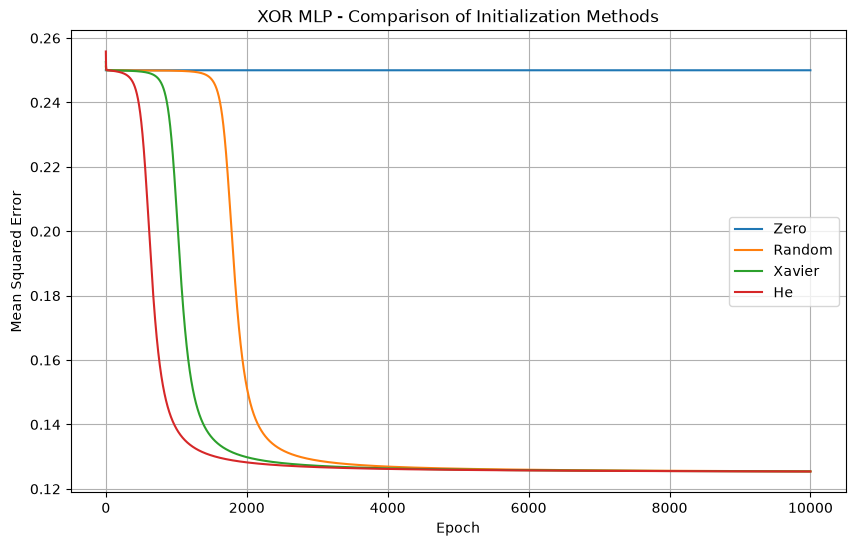



INITIALIZATION COMPARISON
Method         Convergence Epoch        Final Loss     
-----------------------------------------------------------------
zero           Not converged            0.250000       
random         Not converged            0.125457       
xavier         Not converged            0.125416       
he             Not converged            0.125396       

Final hidden weights for ZERO initialization:
[[0. 0.]
 [0. 0.]]

Notice that both hidden neurons have identical weights. Therefore, they learn the same feature.
This is called symmetry breaking failure.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. XOR DATASET
# =========================================================
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=float)


# =========================================================
# 2. SIGMOID FUNCTIONS
# =========================================================
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def sigmoid_derivative(a):
    return a * (1 - a)


# =========================================================
# 3. WEIGHT INITIALIZATION
# =========================================================
def initialize_weights(input_size, hidden_size, output_size,
                       init_method="random", seed=42):

    np.random.seed(seed)

    # ---------------- ZERO INITIALIZATION ----------------
    if init_method == "zero":
        W1 = np.zeros((input_size, hidden_size))
        W2 = np.zeros((hidden_size, output_size))

    # ---------------- RANDOM INITIALIZATION --------------
    elif init_method == "random":
        W1 = np.random.randn(input_size, hidden_size) * 0.5
        W2 = np.random.randn(hidden_size, output_size) * 0.5

    # ---------------- XAVIER INITIALIZATION --------------
    elif init_method == "xavier":
        W1 = np.random.randn(input_size, hidden_size) * np.sqrt(1 / input_size)
        W2 = np.random.randn(hidden_size, output_size) * np.sqrt(1 / hidden_size)

    # ---------------- HE INITIALIZATION ------------------
    elif init_method == "he":
        W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size)
        W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2 / hidden_size)

    else:
        raise ValueError(
            "init_method must be: zero, random, xavier, or he"
        )

    # Biases
    b1 = np.zeros((1, hidden_size))
    b2 = np.zeros((1, output_size))

    return W1, b1, W2, b2


# =========================================================
# 4. MLP TRAINING FUNCTION
# =========================================================
def train_mlp(init_method,
              epochs=10000,
              learning_rate=1.0,
              hidden_size=2,
              convergence_threshold=0.01):

    input_size = X.shape[1]
    output_size = y.shape[1]

    # Initialize weights
    W1, b1, W2, b2 = initialize_weights(
        input_size,
        hidden_size,
        output_size,
        init_method
    )

    losses = []
    convergence_epoch = None

    for epoch in range(epochs):

        # =================================================
        # FORWARD PROPAGATION
        # =================================================

        # Input -> Hidden
        Z1 = np.dot(X, W1) + b1
        A1 = sigmoid(Z1)

        # Hidden -> Output
        Z2 = np.dot(A1, W2) + b2
        A2 = sigmoid(Z2)


        # =================================================
        # LOSS
        # =================================================
        loss = np.mean((A2 - y) ** 2)
        losses.append(loss)


        # =================================================
        # BACKPROPAGATION
        # =================================================

        m = X.shape[0]

        # Output layer
        dA2 = 2 * (A2 - y) / m
        dZ2 = dA2 * sigmoid_derivative(A2)

        dW2 = np.dot(A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        # Hidden layer
        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * sigmoid_derivative(A1)

        dW1 = np.dot(X.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)


        # =================================================
        # UPDATE PARAMETERS
        # =================================================
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2


        # =================================================
        # ZERO INITIALIZATION DEMONSTRATION
        # =================================================
        if init_method == "zero" and epoch in [0, 1, 2, 5, 10]:

            print(f"\nEpoch {epoch + 1}")
            print("Hidden weight matrix W1:")
            print(W1)

            print("\nHidden biases b1:")
            print(b1)


        # =================================================
        # CONVERGENCE CHECK
        # =================================================
        if loss < convergence_threshold and convergence_epoch is None:
            convergence_epoch = epoch + 1


    # Final prediction
    final_hidden = sigmoid(np.dot(X, W1) + b1)
    final_output = sigmoid(np.dot(final_hidden, W2) + b2)

    predictions = (final_output >= 0.5).astype(int)

    return {
        "losses": losses,
        "final_loss": losses[-1],
        "convergence_epoch": convergence_epoch,
        "predictions": predictions,
        "W1": W1,
        "W2": W2
    }


# =========================================================
# 5. TRAIN ALL INITIALIZATION METHODS
# =========================================================
methods = [
    "zero",
    "random",
    "xavier",
    "he"
]

results = {}

for method in methods:

    print("\n" + "=" * 60)
    print("Initialization Method:", method.upper())
    print("=" * 60)

    results[method] = train_mlp(
        init_method=method,
        epochs=10000,
        learning_rate=1.0,
        hidden_size=2,
        convergence_threshold=0.01
    )

    print("\nFinal Loss:")
    print(results[method]["final_loss"])

    print("\nPredictions:")
    print(results[method]["predictions"].flatten())


# =========================================================
# 6. PLOT LOSS CURVES
# =========================================================
plt.figure(figsize=(10, 6))

for method in methods:
    plt.plot(
        results[method]["losses"],
        label=method.capitalize()
    )

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("XOR MLP - Comparison of Initialization Methods")
plt.legend()
plt.grid(True)
plt.show()


# =========================================================
# 7. TABULATE RESULTS
# =========================================================
print("\n")
print("=" * 65)
print("INITIALIZATION COMPARISON")
print("=" * 65)

print(
    f"{'Method':<15}"
    f"{'Convergence Epoch':<25}"
    f"{'Final Loss':<15}"
)

print("-" * 65)

for method in methods:

    convergence = results[method]["convergence_epoch"]

    if convergence is None:
        convergence = "Not converged"

    print(
        f"{method:<15}"
        f"{str(convergence):<25}"
        f"{results[method]['final_loss']:<15.6f}"
    )


# =========================================================
# 8. SHOW ZERO INITIALIZATION SYMMETRY
# =========================================================
print("\nFinal hidden weights for ZERO initialization:")

print(results["zero"]["W1"])

print(
    "\nNotice that both hidden neurons have identical "
    "weights. Therefore, they learn the same feature."
)

print(
    "This is called symmetry breaking failure."
)